# Model  with cross-validation procedure

Imports

In [ ]:
import pickle
import warnings
import os

import mne
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import stats
from sklearn.model_selection import ShuffleSplit
from CVfit import UnfoldModelPyCV

from pathlib import Path
import logging
import sys
sys.path.insert(1, '../')

# from unfold import unfold_model, unfold_utils
from unfold.basic_unfold_model import UnfoldModelPy
from models import models

# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Configure the logger
logging.basicConfig(
    level=logging.DEBUG,  # Set the logging level
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",  # Format of log messages
    handlers=[
        logging.StreamHandler(sys.stdout)  # Log to standard output
    ]
)

logger = logging.getLogger(__name__)

Define picks

In [3]:
picks = [
    'Fp1',
    'AF3',
    'F7',
    'F3',
    'FC1',
    'FC5',
    'T7',
    'C3',
    'CP1',
    'CP5',
    'P7',
    'P3',
    'Pz',
    'PO3',
    'O1',
    'Oz',
    'O2',
    'PO4',
    'P4',
    'P8',
    'CP6',
    'CP2',
    'C4',
    'T8',
    'FC6',
    'FC2',
    'F4',
    'F8',
    'AF4',
    'Fp2',
    'Fz',
    'Cz',
]

## Read events and EEG

In [4]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


## Perform unfolding with CV

Define models to be tested

In [5]:
unfold_models = {
    'baseline': UnfoldModelPy(models.get_baseline_model()),
    'go': UnfoldModelPy(models.get_go_model()),
    'stop': UnfoldModelPy(models.get_stop_model()),
    'response': UnfoldModelPy(models.get_full_model()),
    'full_stop_type': UnfoldModelPy(models.get_full_stop_type_model()),
    'full_stop_type_ssd': UnfoldModelPy(models.get_full_stop_type_ssd_model()),
    'full_stop_type_sri': UnfoldModelPy(models.get_full_stop_type_sri_model()),
    'full_interactions': UnfoldModelPy(models.get_full_interaction_model())
}

Create dirs for CV results

In [6]:
results_main_path = '../data/cv'

for key in unfold_models.keys():
    path = Path(f"{results_main_path}/{key}")
    path.mkdir(parents=True, exist_ok=True)

In [7]:
file_names = file_names[:6]
file_names

['AB0407_SST14_EOG4',
 'AB2407_SST14_new_EOG4',
 'AD1406_SST14_EOG4',
 'AF0905_SST14_EOG4',
 'AK0102_SST14_EOG4',
 'AR1607_SST14_EOG4']

Perform cross-validation on models

In [ ]:
# define splitting strategy
cv=ShuffleSplit(n_splits=3, random_state=42, test_size=0.50)

for file_name in file_names:
    # read events dict
    with open(f'{events_data_dir}/{file_name}.pickle', 'rb') as handle:
        events = pickle.load(handle) # events dict channel_name:events_df

    # read EEG
    raw = mne.io.read_raw_brainvision(
        f'{eeg_data_dir}/{file_name}.vhdr',
        preload=True,
        eog=('HEOG', 'VEOG'),
    ).pick(picks=picks)

    for unfold_model_name, current_unfold_model in unfold_models.items():
        unfold_model_cv = UnfoldModelPyCV(estimator=current_unfold_model)
        unfold_model_cv.fit_unfold_model(raw, events, cv=cv, as_epochs=True, refit=False, channels=['Cz', 'Fz'])
        
        # save CV results
        unfold_model_cv.save_cv_results(f"{results_main_path}/{unfold_model_name}/{file_name}")

---
## Compare models

In [15]:
# TODO

In [9]:
# Configure the logger
logging.basicConfig(
    level=logging.INFO,  # Set the logging level
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",  # Format of log messages
    handlers=[
        logging.StreamHandler(sys.stdout)  # Log to standard output
    ]
)

logger = logging.getLogger(__name__)

In [10]:
def calculate_brain_score(
        cv_results,
        test=True,
        crop=(0,0.5),
        sfreq=64,
        epoch_lim = (-0.2, 1.58)
):
    if test:
        variable = 'test'
    else:
        variable = 'train'

    person_results = {}
    for channel in cv_results.keys():
        test_original_cvs = cv_results[channel][f'{variable}_original'].to_numpy()
        test_predicted_cvs = cv_results[channel][f'{variable}_predicted'].to_numpy()

        # epochs: -0.2 to 1.58 ms -> 0 to 114
        if crop is None:
            t_min, t_max = epoch_lim
        else:
            t_min, t_max = crop

        # calculate time window in timepoints
        t_min_tp = int((t_min - epoch_lim[0])*sfreq)
        t_max_tp = int((t_max - epoch_lim[0])*sfreq)

        # iterate over cv repeats
        cv_pearsons_r = []
        for i, (original, predicted) in enumerate(zip(test_original_cvs, test_predicted_cvs)):
            original_cropped = np.array(original)[:, t_min_tp:t_max_tp]
            predicted_cropped = np.array(predicted)[:, t_min_tp:t_max_tp]

            original_cropped_flatten = original_cropped.flatten()
            predicted_cropped_flatten = predicted_cropped.flatten()

            # calculate pearsons r
            r = np.corrcoef(original_cropped_flatten, predicted_cropped_flatten)[0, 1]
            cv_pearsons_r.append(r)

        cv_pearsons_r = np.array(cv_pearsons_r)
        r_mean = cv_pearsons_r.mean()
        r_sd = cv_pearsons_r.std()

        person_results[channel] = {'cv_pearsons_r': cv_pearsons_r, 'cv_mean': r_mean, 'cv_std': r_sd}

    return person_results

In [11]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


Test

In [12]:
file_names = file_names[:6]
results_main_path = '../data/cv'

unfold_models = ['baseline', 'go', 'stop', 'response', 'full_stop_type', 'full_stop_type_ssd',
                 'full_stop_type_sri', 'full_interactions']

models_results_aggregation = []
for file_name in file_names:
    models_pearsons_r = {}
    for model in unfold_models:
        with open(f'{results_main_path}/{model}/{file_name}_cv.pickle', 'rb') as handle:
            cv_results = pickle.load(handle)
            pearsons_r_results = calculate_brain_score(
                cv_results,
                test=True,
                crop=(.7, 1.5)
            )
            models_pearsons_r[model] = pearsons_r_results
    models_results_aggregation.append(models_pearsons_r)

In [ ]:
channel = 'Cz'
for i, person_results in enumerate(models_results_aggregation):
    plt.figure(i)
    for model_name, pearsons_r_results in person_results.items():
        data = pearsons_r_results[channel]['cv_pearsons_r']
        plt.hist(data, label=f"{model_name}: {np.mean(data):.3f}")

    plt.legend()

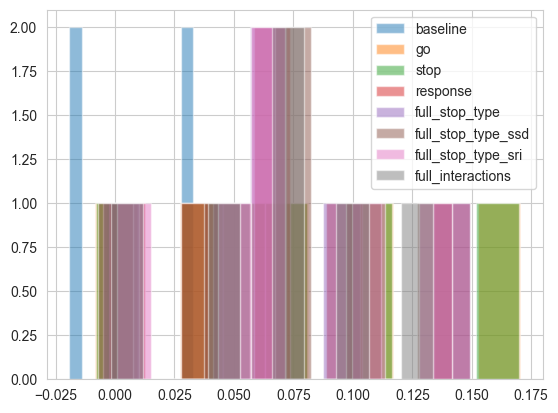

In [14]:
channel = 'Cz'
person_model_agg = {}

# Loop through individual results
for i, person_results in enumerate(models_results_aggregation):
    for model_name, pearsons_r_results in person_results.items():
        # Initialize the list for each model if not already done
        if model_name not in person_model_agg:
            person_model_agg[model_name] = []
        # Append the result for the specific channel
        person_model_agg[model_name].append(pearsons_r_results[channel]['cv_mean'])

# Plot the histograms
for model_name, results in person_model_agg.items():
    plt.hist(results, label=model_name, alpha=0.5)  # Use alpha for better overlay visibility
plt.legend()